# Surrogate/oracle design — dual datasets, **output PCA** targets

Two coordinated train/val/test splits to pick a **surrogate** (dataset 1) and **oracle** (dataset 2):
val sets disjoint, `S_test ⊆ O_train`, `O_test ⊆ S_train`; per-sample dual labels saved for in-sample/OOD
design eval.

Models predict a **PCA-reduced spectrum** (32 components, fit on each dataset's train spectra) instead of the
raw 1002-dim curve — fewer output params, denoised target, less overfitting; reconstructed for all metrics/plots.
Compared: 5 MLP readouts (mean/min/max/std/concat) and 5 CNNs (mean/min/max/std/concat), param-matched.

## 0. Setup + data + per-residue embeddings

In [15]:
import csv, os, numpy as np, torch, torch.nn as nn, hashlib
import arcadia_pycolor as apc, fp_models as fpm
from sklearn.decomposition import PCA
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
H=np.load(os.path.join(TD,"esm_residue_fp16.npy")); Ls=np.load(os.path.join(TD,"esm_residue_len.npy")); Lmax=H.shape[1]
Ht=torch.tensor(H); ar=torch.arange(Lmax); os.makedirs("trained_models",exist_ok=True)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N)

device mps | N 453


## 1. Two coordinated splits (+ dual labels)

In [16]:
SPLIT_SEED=0
rng=np.random.default_rng(SPLIT_SEED); perm=rng.permutation(N)
n_te=int(round(0.15*N)); n_va=int(round(0.15*N))
Srole=np.array(["train"]*N); Srole[perm[:n_te]]="test"; Srole[perm[n_te:n_te+n_va]]="val"
s_train=perm[n_te+n_va:]
st=np.random.default_rng(SPLIT_SEED+1).permutation(s_train)
Orole=np.array(["train"]*N); Orole[st[:n_te]]="test"; Orole[st[n_te:n_te+n_va]]="val"
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
assert np.sum((Srole=="val")&(Orole=="val"))==0
def cnt(a): return {b:int((a==b).sum()) for b in("train","val","test")}
print("surrogate (S):", cnt(Srole), "| oracle (O):", cnt(Orole))
with open(os.path.join(TD,"dual_splits.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","slug","name","surrogate_role","oracle_role"])
    for i,r in enumerate(rows): w.writerow([i,r.get("slug",""),r.get("name",""),Srole[i],Orole[i]])
SIDX={b:np.where(Srole==b)[0] for b in("train","val","test")}
OIDX={b:np.where(Orole==b)[0] for b in("train","val","test")}

surrogate (S): {'train': 317, 'val': 68, 'test': 68} | oracle (O): {'train': 317, 'val': 68, 'test': 68}


surrogate-role -> oracle-role contingency:
  S_train -> O_train 181, O_val 68, O_test 68
  S_val   -> O_train 68, O_val 0, O_test 0
  S_test  -> O_train 68, O_val 0, O_test 0


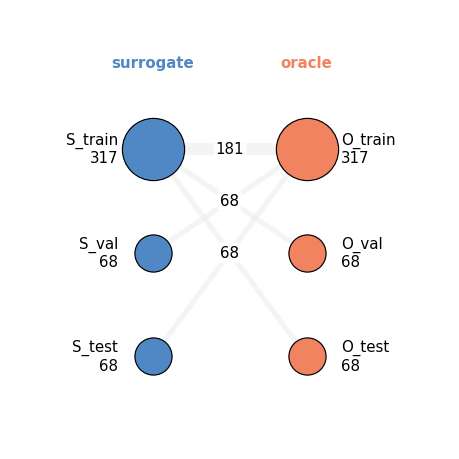

In [17]:
# Bipartite map of the dual split: surrogate roles (left) -> oracle roles (right); edge = # shared sequences
roles=["train","val","test"]
M={(s,o):int(((Srole==s)&(Orole==o)).sum()) for s in roles for o in roles}
Stot={s:int((Srole==s).sum()) for s in roles}; Otot={o:int((Orole==o).sum()) for o in roles}
print("surrogate-role -> oracle-role contingency:")
for s in roles: print(f"  S_{s:5s} -> "+", ".join(f"O_{o} {M[(s,o)]}" for o in roles))
if HAVE_PLT:
    yp={"train":2,"val":1,"test":0}; LX,RX=0.0,2.0; cmax=max(M.values())
    fig,ax=plt.subplots(figsize=(6,6))
    for s in roles:
        for o in roles:
            c=M[(s,o)]
            if c==0: continue
            ax.plot([LX,RX],[yp[s],yp[o]], lw=1.2+11*c/cmax, color=apc.gray, alpha=0.5, zorder=1, solid_capstyle="round")
            t=0.5#0.30 if s=="train" else 0.70                       # stagger labels so they don't collide
            ax.text(LX+t*(RX-LX), yp[s]+t*(yp[o]-yp[s]), str(c), ha="center", va="center", fontsize=15, zorder=3,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    for s in roles:
        ax.scatter([LX],[yp[s]], s=700+10*Stot[s], color=apc.aegean, ec="k", lw=1.2, zorder=2)
        ax.text(LX-0.45, yp[s], f"S_{s}\n{Stot[s]}", ha="right", va="center", fontsize=15)
    for o in roles:
        ax.scatter([RX],[yp[o]], s=700+10*Otot[o], color=apc.amber, ec="k", lw=1.2, zorder=2)
        ax.text(RX+0.45, yp[o], f"O_{o}\n{Otot[o]}", ha="left", va="center", fontsize=15)
    ax.text(LX, 2.78, "surrogate", ha="center", fontsize=15, color=apc.aegean, fontweight="bold")
    ax.text(RX, 2.78, "oracle",    ha="center", fontsize=15, color=apc.amber,  fontweight="bold")
    ax.set_xlim(-1.6,3.6); ax.set_ylim(-0.7,3.15); ax.axis("off")
    plt.tight_layout(); plt.show()

## 2. Models (param-matched, PCA-coeff output) + train/eval + cache

PCA (32 comps) is fit per dataset on its **train** spectra. Each base net regresses the coefficients, then a
`NormalizedSpectrum` wrapper bakes the **PCA inverse_transform** and **per-half (ex|em) peak-normalization**
into the model, so `forward()` returns a spectrum that maxes at 1. Training minimizes a **cosine-similarity
loss** (shape match) in this normalized spectrum space; model selection / early-stopping use validation MSE.
Only the base coeff-net is saved; the PCA basis is re-attached on load (`load_wrapped`).

In [18]:
PCA_N=32; DROP=0.2; LR=1e-3; WD=1e-4; EP_MLP=300; EP_CNN=150; FORCE=False
cnn_ref=fpm.SpectrumNet("max",True,conv_ch=128,k=5,hidden=256,nl=2,out=PCA_N)
BUDGET=sum(p.numel() for p in cnn_ref.parameters())
def mlp_hidden(d_in,nl=4,out=PCA_N):
    pf=lambda Hd: d_in*Hd+Hd+(nl-1)*(Hd*Hd+Hd)+Hd*out+out
    return min(range(32,2049,4), key=lambda Hd: abs(pf(Hd)-BUDGET))
MODELS=[]
for inp in ["mean","min","max","std","concat"]:
    d_in=1280*(4 if inp=="concat" else 1)
    MODELS.append(dict(type="mlp", input=inp, hidden=mlp_hidden(d_in), nl=4, sid=f"mlp-{inp}"))
for pool in ["mean","min","max","std","concat"]:
    MODELS.append(dict(type="cnn", pool=pool, sid=f"cnn-{pool}"))
# target spectra are already per-half peak-normalized (build_fpbase_dataset.py)
Yt=torch.tensor(Y, dtype=torch.float32, device=dev)

def build_base(spec):                                          # base net predicts PCA_N coefficients
    if spec["type"]=="mlp":
        return fpm.PooledMLP(spec["input"], spec["hidden"], spec["nl"], out=PCA_N, drop=DROP).to(dev)
    return fpm.SpectrumNet(spec["pool"], True, conv_ch=128, k=5, hidden=256, nl=2, out=PCA_N, drop=DROP).to(dev)
def wrap(base, pca):                                           # PCA inverse_transform + per-half peak-norm baked into the model
    return fpm.NormalizedSpectrum(base, pca.components_, pca.mean_, G).to(dev)
def load_wrapped(path, pca):
    base,ck=fpm.load_model(path,dev,out=PCA_N); return wrap(base,pca), ck

def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def predict_spectrum(net, idx, pca=None):                     # wrapped net already returns a normalized spectrum
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
def cos_sim(P,T):                                             # mean per-half (ex|em) cosine similarity
    def cs(a,b): return (a*b).sum(1)/(np.linalg.norm(a,axis=1)*np.linalg.norm(b,axis=1)+1e-8)
    return float(0.5*(cs(P[:,:G],T[:,:G])+cs(P[:,G:],T[:,G:])).mean())
def evaluate(net, idx, pca=None):
    P=predict_spectrum(net, idx); T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()), cos=cos_sim(P,T), em_mae=float(np.abs(em-EMM[idx]).mean()))
def fit(net, tr, va, epochs):                                 # train with cosine-similarity loss in (normalized) spectrum space
    opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD); best=1e9; bst=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad()
            fpm.cosine_loss(net(Hb,mk), Yt[torch.as_tensor(b,device=dev)], G).backward()
            opt.step()
        v=evaluate(net,va)["mse"]                             # select / early-stop on val MSE
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.base.state_dict().items()}
    net.base.load_state_dict(bst); return net

DATASIG=hashlib.md5(Srole.tobytes()+Orole.tobytes()).hexdigest()[:8]
def get_or_train(spec, dsname, tr, va, te, pca):
    path=os.path.join("trained_models", f"dual_{dsname}_{spec['sid']}_pca{PCA_N}_cos_{DATASIG}.pt")
    if os.path.exists(path) and not FORCE:
        net,_=load_wrapped(path, pca)
        met={"train":evaluate(net,tr), "val":evaluate(net,va), "test":evaluate(net,te)}   # recompute (adds cosine)
        return met, True, path
    net=wrap(build_base(spec), pca); fit(net, tr, va, EP_MLP if spec["type"]=="mlp" else EP_CNN)
    met={"train":evaluate(net,tr), "val":evaluate(net,va), "test":evaluate(net,te)}
    if spec["type"]=="mlp":
        meta=dict(kind="pooledmlp", input=spec["input"], hidden=spec["hidden"], nl=spec["nl"], drop=DROP, out=PCA_N)
    else:
        meta=dict(kind="spectrumnet", arch="CNN", pool=spec["pool"], conv_ch=128, k=5, hidden=256, nl=2, drop=DROP, out=PCA_N)
    meta.update(sid=spec["sid"], metrics=met, loss="cosine")
    fpm.save_model(path, net.base, meta); return met, False, path     # save the base coeff-net; PCA re-attached on load
print("budget (CNN, out=PCA):", f"{BUDGET:,}")

budget (CNN, out=PCA): 1,008,416


## 3-4. Run both datasets → pick surrogate (dataset 1) and oracle (dataset 2)

In [19]:
def run(dsname, IDX):
    pca=PCA(PCA_N, random_state=0).fit(Y[IDX["train"]])
    print(f"=== {dsname} dataset === (PCA {PCA_N} comps, EVR {pca.explained_variance_ratio_.sum():.3f})")
    table=[]
    for spec in MODELS:
        met,cached,path=get_or_train(spec, dsname, IDX["train"], IDX["val"], IDX["test"], pca)
        table.append((spec,met,path))
        print(f"  {spec['sid']:11s} {'(cached)' if cached else '(trained)'} | "
              f"train cos {met['train']['cos']:.3f} | val cos {met['val']['cos']:.3f} mse {met['val']['mse']:.5f} em {met['val']['em_mae']:4.1f} | "
              f"test cos {met['test']['cos']:.3f} mse {met['test']['mse']:.5f} em {met['test']['em_mae']:4.1f}")
    best=min(table, key=lambda t: t[1]["val"]["mse"])         # select by val MSE (cosine is reported but not used to rank)
    print(f"  -> best by val mse: {best[0]['sid']} (mse {best[1]['val']['mse']:.5f}, cos {best[1]['val']['cos']:.3f})")
    return table, best, pca

surr_table, surr_best, surr_pca = run("surr", SIDX)
orac_table, orac_best, orac_pca = run("orac", OIDX)

=== surr dataset === (PCA 32 comps, EVR 0.995)
  mlp-mean    (cached) | train cos 0.919 | val cos 0.761 mse 0.04180 em 24.4 | test cos 0.811 mse 0.03406 em 17.8
  mlp-min     (cached) | train cos 0.828 | val cos 0.757 mse 0.04889 em 28.2 | test cos 0.785 mse 0.04456 em 20.8
  mlp-max     (cached) | train cos 0.825 | val cos 0.755 mse 0.05182 em 27.8 | test cos 0.789 mse 0.04406 em 20.1
  mlp-std     (cached) | train cos 0.744 | val cos 0.790 mse 0.05989 em 21.8 | test cos 0.754 mse 0.06443 em 32.2
  mlp-concat  (cached) | train cos 0.843 | val cos 0.760 mse 0.04843 em 26.8 | test cos 0.787 mse 0.04217 em 21.1
  cnn-mean    (cached) | train cos 0.918 | val cos 0.740 mse 0.04511 em 27.4 | test cos 0.804 mse 0.03432 em 17.4
  cnn-min     (cached) | train cos 0.959 | val cos 0.752 mse 0.04129 em 26.9 | test cos 0.815 mse 0.03601 em 24.1
  cnn-max     (cached) | train cos 0.981 | val cos 0.789 mse 0.03263 em 22.3 | test cos 0.867 mse 0.02255 em 12.8
  cnn-std     (cached) | train cos 0.960 

## 5. Save chosen models + train/val/test bars

surrogate (dataset 1) <- cnn-max | val cos 0.789 mse 0.03263
oracle    (dataset 2) <- cnn-max | val cos 0.835 mse 0.03249


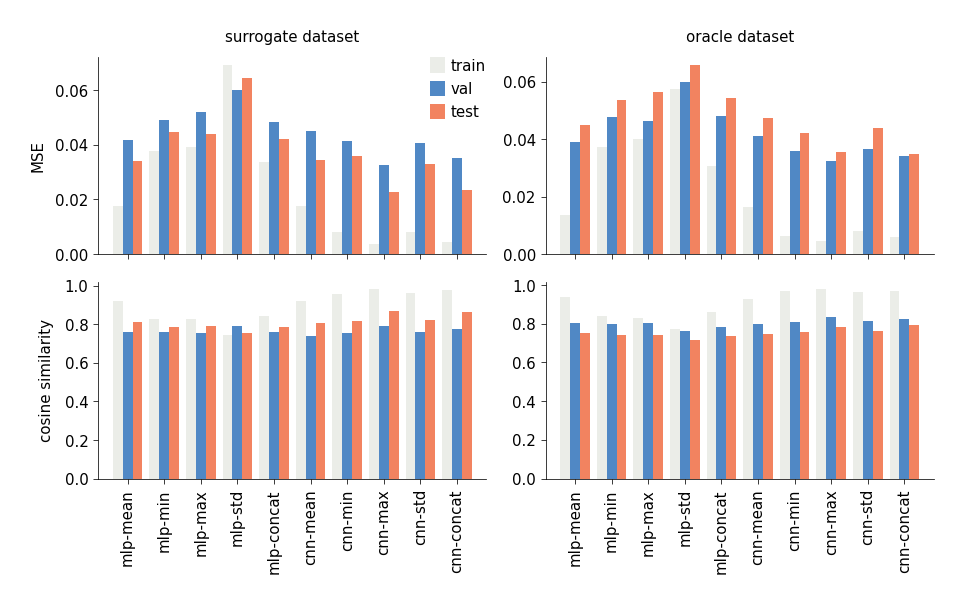

In [20]:
import shutil
# surrogate and oracle both use the CNN max-pool readout (cnn-max)
surr_pick=next(t for t in surr_table if t[0]["sid"]=="cnn-max")
orac_pick=next(t for t in orac_table if t[0]["sid"]=="cnn-max")
shutil.copy(surr_pick[2], os.path.join("trained_models","dual_surrogate_net.pt"))
shutil.copy(orac_pick[2], os.path.join("trained_models","dual_oracle_net.pt"))
import joblib
joblib.dump(surr_pca, os.path.join("trained_models","dual_surrogate_pca.joblib"))   # surrogate net predicts in this PCA basis
joblib.dump(orac_pca, os.path.join("trained_models","dual_oracle_pca.joblib"))       # oracle net predicts in this PCA basis
print(f"surrogate (dataset 1) <- {surr_pick[0]['sid']} | val cos {surr_pick[1]['val']['cos']:.3f} mse {surr_pick[1]['val']['mse']:.5f}")
print(f"oracle    (dataset 2) <- {orac_pick[0]['sid']} | val cos {orac_pick[1]['val']['cos']:.3f} mse {orac_pick[1]['val']['mse']:.5f}")
if HAVE_PLT:
    ylab={"mse":"MSE","cos":"cosine similarity"}
    fig,ax=plt.subplots(2,2,figsize=(13,8),sharex="col")
    for col,(name,tbl) in enumerate([("surrogate dataset",surr_table),("oracle dataset",orac_table)]):
        sids=[s["sid"] for s,_,_ in tbl]; x=np.arange(len(sids)); w=0.27
        for row,metric in enumerate(["mse","cos"]):
            a=ax[row,col]
            tr=[m["train"][metric] for _,m,_ in tbl]; vv=[m["val"][metric] for _,m,_ in tbl]; tt=[m["test"][metric] for _,m,_ in tbl]
            a.bar(x-w,tr,w,color=apc.gray,label="train"); a.bar(x,vv,w,color=apc.aegean,label="val"); a.bar(x+w,tt,w,color=apc.amber,label="test")
            a.set_xticks(x); a.set_xticklabels(sids,rotation=90)
            if row==0: a.set_title(name)
            if col==0: a.set_ylabel(ylab[metric])
    ax[0,0].legend()
    plt.tight_layout(); plt.show()

## 6. Surrogate top-5: example-by-example on validation

Ground truth = rose, prediction = blue (ex dashed, em solid); the same validation proteins across all top-5 models.

top-5 (S_val MSE): ['cnn-max mse 0.0326 cos 0.789', 'cnn-concat mse 0.0350 cos 0.775', 'cnn-std mse 0.0405 cos 0.761', 'cnn-min mse 0.0413 cos 0.752', 'mlp-mean mse 0.0418 cos 0.761']


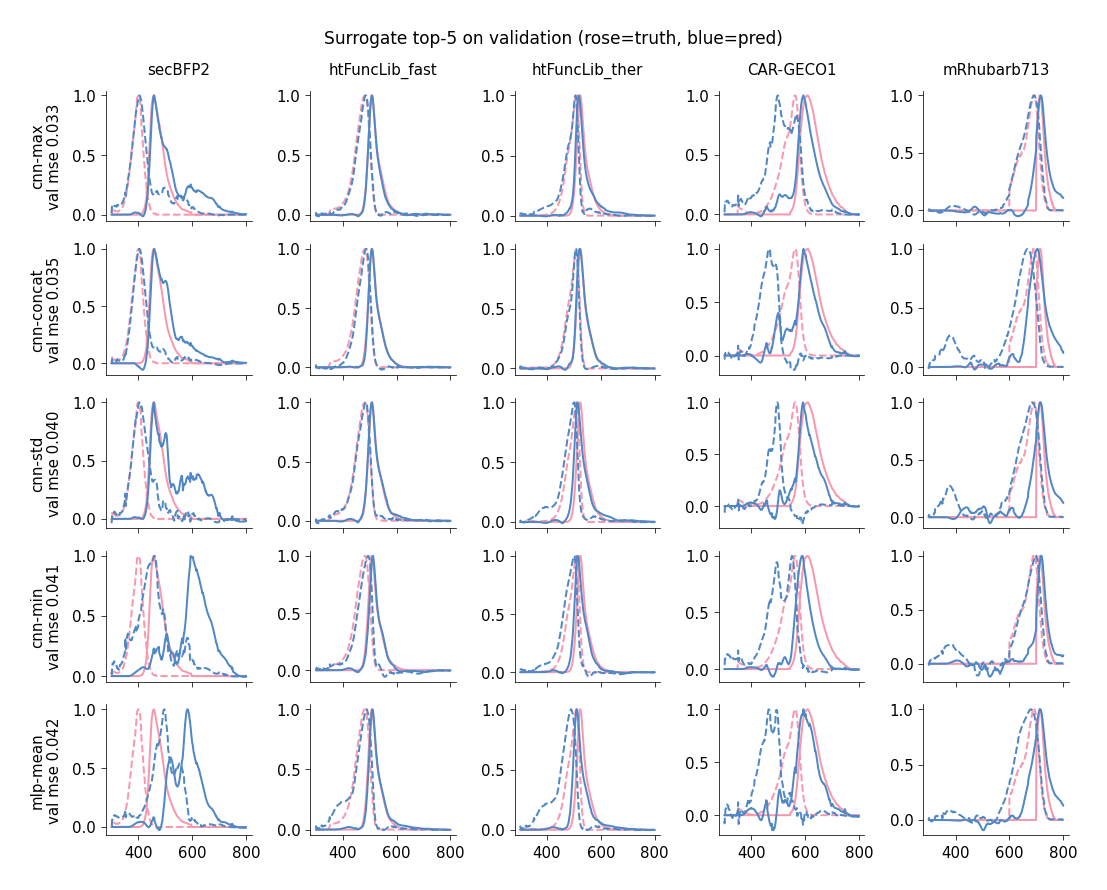

In [21]:
def span(idx,k):
    idx=np.array(idx); order=idx[np.argsort(EMM[idx])]
    return order[np.linspace(0,len(order)-1,min(k,len(order))).astype(int)]
K=5
top5=sorted(surr_table, key=lambda t: t[1]["val"]["mse"])[:5]
print("top-5 (S_val MSE):", [f"{t[0]['sid']} mse {t[1]['val']['mse']:.4f} cos {t[1]['val']['cos']:.3f}" for t in top5])
vex=span(SIDX["val"], K)
if HAVE_PLT:
    fig,axes=plt.subplots(len(top5),K,figsize=(3*K,2.4*len(top5)),sharex=True)
    for r,(spec,met,path) in enumerate(top5):
        net,_=load_wrapped(path,surr_pca); P=predict_spectrum(net,vex)
        for c,i in enumerate(vex):
            a=axes[r,c]
            a.plot(grid,Y[i,:G],color=apc.rose,ls="--"); a.plot(grid,Y[i,G:],color=apc.rose,ls="-")
            a.plot(grid,P[c,:G],color=apc.aegean,ls="--"); a.plot(grid,P[c,G:],color=apc.aegean,ls="-")
            if r==0: a.set_title(rows[i]["name"][:14])
            if c==0: a.set_ylabel(f"{spec['sid']}\nval mse {met['val']['mse']:.3f}")
    plt.suptitle("Surrogate top-5 on validation (rose=truth, blue=pred)"); plt.tight_layout(); plt.show()

### 6b. Parity scatter — predicted vs true peak (top-5, train vs val)

Predicted vs true ex_max (top) and em_max (bottom); train=blue, val=amber, dashed y=x.

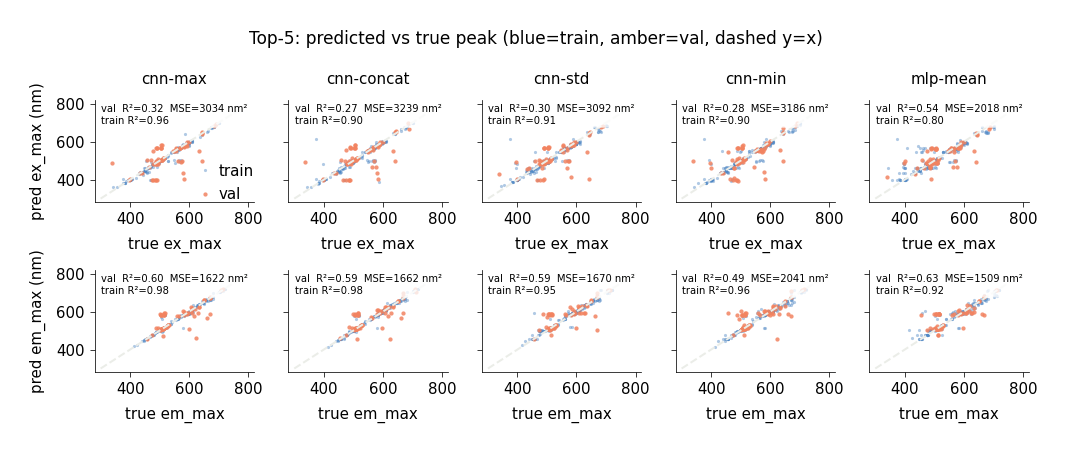

In [25]:
def pred_peaks(net, idx, pca=None):
    P=predict_spectrum(net, idx); return grid[np.argmax(P[:,:G],1)], grid[np.argmax(P[:,G:],1)]
def _r2(t,p):
    t=np.asarray(t,float); p=np.asarray(p,float); ss=((t-t.mean())**2).sum()
    return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
if HAVE_PLT:
    lo,hi=float(grid[0]),float(grid[-1])
    fig,axes=plt.subplots(2,len(top5),figsize=(2.9*len(top5),5.8),sharex='row',sharey='row')
    for c,(spec,met,path) in enumerate(top5):
        net,_=load_wrapped(path,surr_pca)
        ex_tr,em_tr=pred_peaks(net,SIDX["train"]); ex_va,em_va=pred_peaks(net,SIDX["val"])
        for row,(tt,pt,tv,pv,lab) in enumerate([
            (EXM[SIDX["train"]],ex_tr,EXM[SIDX["val"]],ex_va,"ex_max"),
            (EMM[SIDX["train"]],em_tr,EMM[SIDX["val"]],em_va,"em_max")]):
            a=axes[row,c]; a.plot([lo,hi],[lo,hi],ls="--",color=apc.gray)
            a.scatter(tt,pt,s=10,color=apc.aegean,alpha=0.45,label="train")
            a.scatter(tv,pv,s=18,color=apc.amber,alpha=0.85,label="val")
            msev=float(np.mean((np.asarray(pv)-np.asarray(tv))**2))                  # val peak MSE (nm^2)
            a.text(0.04,0.96, f"val  R²={_r2(tv,pv):.2f}  MSE={msev:.0f} nm²\ntrain R²={_r2(tt,pt):.2f}",
                   transform=a.transAxes, va="top", ha="left", fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
            if row==0: a.set_title(spec["sid"])
            if c==0: a.set_ylabel(f"pred {lab} (nm)")
            a.set_xlabel(f"true {lab}")
    axes[0,0].legend(loc="lower right")
    plt.suptitle("Top-5: predicted vs true peak (blue=train, amber=val, dashed y=x)"); plt.tight_layout(); plt.show()

## 7. Oracle by split region (dual labels)

Best oracle model on three regions. **Ground truth = rose, oracle prediction = seaweed.**
- **S_train ∩ O_train** — oracle in-sample.
- **S_test ∩ O_train** (=surrogate-test) — oracle in-sample, surrogate-OOD (judges OOD designs here).
- **S_train ∩ O_test** (=oracle-test) — oracle held-out (certifies its accuracy).

oracle = cnn-max
region                    n      MSE  cosine  em_MAE
S_train ∩ O_train       181  0.00402   0.979     4.7
S_test ∩ O_train         68  0.00337   0.984     3.2
S_train ∩ O_test         68  0.03547   0.786    22.1


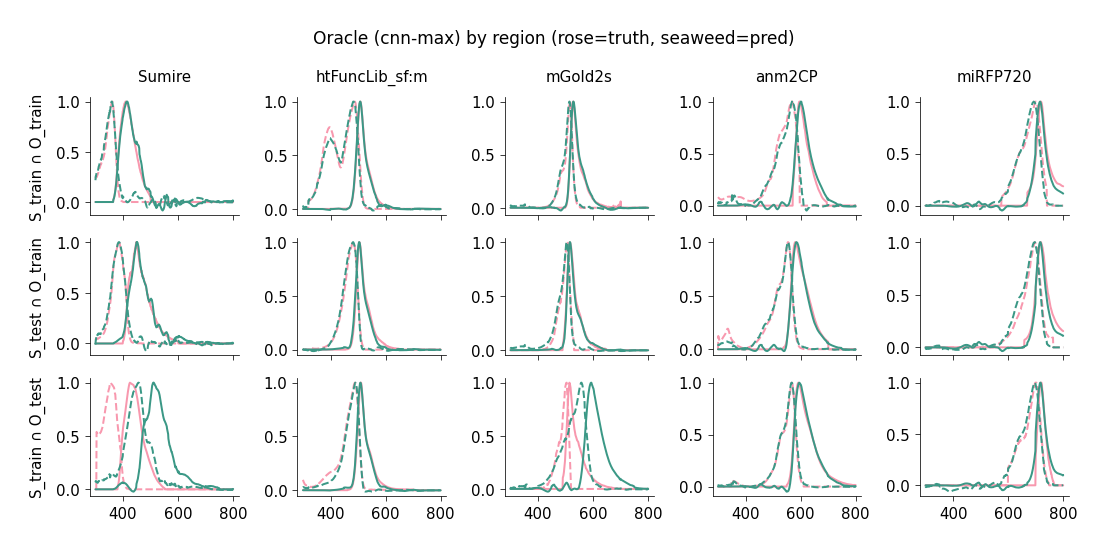

In [23]:
oracle_net,_=load_wrapped(orac_pick[2], orac_pca)
groups=[("S_train ∩ O_train", np.intersect1d(SIDX["train"],OIDX["train"])),
        ("S_test ∩ O_train",  np.intersect1d(SIDX["test"], OIDX["train"])),
        ("S_train ∩ O_test",  np.intersect1d(SIDX["train"],OIDX["test"]))]
print(f"oracle = {orac_pick[0]['sid']}")
print(f"{'region':22s} {'n':>4} {'MSE':>8} {'cosine':>7} {'em_MAE':>7}")
for name,idx in groups:
    m=evaluate(oracle_net, idx, orac_pca)
    print(f"{name:22s} {len(idx):>4} {m['mse']:8.5f} {m['cos']:7.3f} {m['em_mae']:7.1f}")
if HAVE_PLT:
    fig,axes=plt.subplots(len(groups),K,figsize=(3*K,2.4*len(groups)),sharex=True)
    for r,(name,idx) in enumerate(groups):
        ex=span(idx,K); P=predict_spectrum(oracle_net,ex,orac_pca)
        for c,i in enumerate(ex):
            a=axes[r,c]
            a.plot(grid,Y[i,:G],color=apc.rose,ls="--"); a.plot(grid,Y[i,G:],color=apc.rose,ls="-")
            a.plot(grid,P[c,:G],color=apc.seaweed,ls="--"); a.plot(grid,P[c,G:],color=apc.seaweed,ls="-")
            if r==0: a.set_title(rows[i]["name"][:14])
            if c==0: a.set_ylabel(name)
    plt.suptitle(f"Oracle ({orac_pick[0]['sid']}) by region (rose=truth, seaweed=pred)"); plt.tight_layout(); plt.show()

## Notes
- Output is **PCA-reduced** (32 comps, fit per dataset on train). All metrics/plots are in reconstructed
  spectrum space. Cache key includes `pcaN`, so PCA and non-PCA checkpoints don't collide.
- `dual_splits.csv` labels each FP with surrogate/oracle roles for in-sample vs OOD design evaluation.